# 第八章配套实验：Newton 法为什么快？什么时候要小心？

这个 Notebook 配合“牛顿法”课件使用，重点不是背公式，而是通过实验观察：

1. Newton 法如何利用曲率信息减少迭代次数；
2. GD、Newton、阻尼 Newton、Gauss-Newton 在迭代次数和运行时间上的差异；
3. 非凸问题中 Newton 为什么可能不是下降方向；
4. Newton 法在非线性最小二乘和内点法中的实际形态。

课堂建议：先运行公共函数，再按实验顺序运行。最后一节会汇总不同实验的迭代次数和 runtime。

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PICS = BASE / "pics"
PICS.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

SHANSHU = "#841e34"
BLUE = "#46445D"
DEEP_GREEN = "#0A6B3A"
ORANGE = "#AC7088"
HALF_GRAY = "0.55"

summaries = []


def timed_run(fn, repeats=1):
    start = perf_counter()
    result = None
    for _ in range(repeats):
        result = fn()
    elapsed = (perf_counter() - start) / repeats
    return result, elapsed


def add_summary(experiment, method, iterations, runtime, final_loss, note=""):
    summaries.append({
        "experiment": experiment,
        "method": method,
        "iterations": iterations,
        "runtime_sec": runtime,
        "final_loss": final_loss,
        "note": note,
    })

print(f"图片会保存到: {PICS}")

图片会保存到: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics


## 实验 1：病态二次函数上比较 GD 与 Newton

考虑二维严格凸二次函数

$$
f(x)=\frac12 x^TQx,\qquad Q=\begin{pmatrix}1&0\\0&\kappa\end{pmatrix}.
$$

它的梯度和 Hessian 分别为

$$
\nabla f(x)=Qx,\qquad \nabla^2 f(x)=Q.
$$

最优点显然是

$$
x^\star=(0,0)^T,
$$

因为 $Q\succ0$，所以这是唯一全局最小点。

这里的关键参数是条件数

$$
\operatorname{cond}(Q)=\kappa.
$$

当 $\kappa$ 很大时，等高线会变成非常狭长的椭圆。GD 沿负梯度方向走，容易在陡峭方向来回震荡，在平坦方向推进很慢；Newton 法解

$$
Qd^k=-Qx^k
$$

会直接利用 Hessian 的尺度信息。对严格二次函数，Newton 理论上一步到达最优点。

本实验比较不同 $\kappa$ 下 GD 与 Newton 的迭代次数和 runtime。注意：这里 runtime 是小规模 Python 实验的运行时间，教学上更应关注迭代次数随条件数变化的趋势。

,kappa,method,iterations,runtime_sec,final_loss
0,10,"GD, alpha=2/(L+mu)",58,0.004413,7.189875e-09
1,10,Newton,1,0.000100,0.000000e+00
2,50,"GD, alpha=2/(L+mu)",288,0.010325,4.054568e-08
3,50,Newton,1,0.000067,0.000000e+00
4,100,"GD, alpha=2/(L+mu)",576,0.026524,8.004698e-08
5,100,Newton,1,0.000087,0.000000e+00
6,500,"GD, alpha=2/(L+mu)",2879,0.129536,3.987780e-07
7,500,Newton,1,0.000080,0.000000e+00


saved to D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\chapter8_newton_quadratic_gd_vs_newton.png


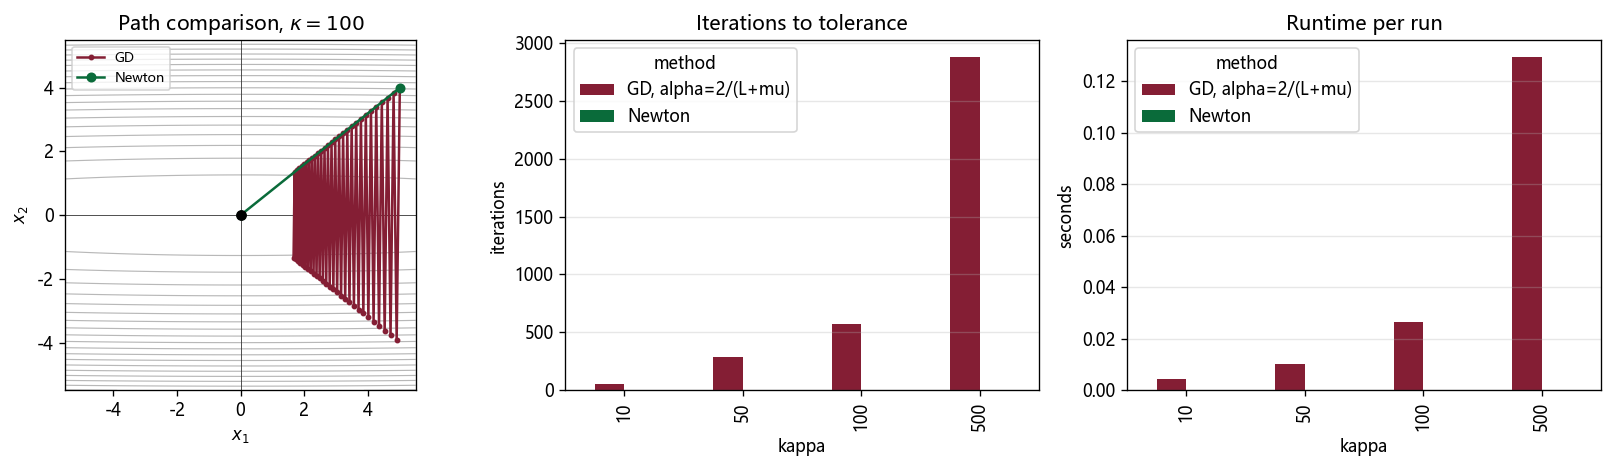

In [2]:
def quad_f(x, Q):
    return 0.5 * float(x @ Q @ x)


def quad_grad(x, Q):
    return Q @ x


def gd_quadratic(Q, x0, alpha, tol=1e-10, max_iter=200000):
    x = np.array(x0, dtype=float)
    f0 = max(quad_f(x, Q), 1e-300)
    xs = [x.copy()]
    fs = [quad_f(x, Q)]
    for _ in range(max_iter):
        x = x - alpha * quad_grad(x, Q)
        xs.append(x.copy())
        fs.append(quad_f(x, Q))
        if fs[-1] / f0 <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e12:
            break
    return np.array(xs), np.array(fs)


def newton_quadratic(Q, x0, tol=1e-10, max_iter=20):
    x = np.array(x0, dtype=float)
    f0 = max(quad_f(x, Q), 1e-300)
    xs = [x.copy()]
    fs = [quad_f(x, Q)]
    for _ in range(max_iter):
        g = quad_grad(x, Q)
        d = np.linalg.solve(Q, -g)
        x = x + d
        xs.append(x.copy())
        fs.append(quad_f(x, Q))
        if fs[-1] / f0 <= tol:
            break
    return np.array(xs), np.array(fs)


def plot_quad_contours(ax, Q, lim=5.5, levels=24):
    grid = np.linspace(-lim, lim, 350)
    X, Y = np.meshgrid(grid, grid)
    Z = 0.5 * (Q[0, 0] * X**2 + 2 * Q[0, 1] * X * Y + Q[1, 1] * Y**2)
    ax.contour(X, Y, Z, levels=levels, colors="0.72", linewidths=0.7)
    ax.axhline(0, color="0.2", linewidth=0.5)
    ax.axvline(0, color="0.2", linewidth=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")


def run_quadratic_comparison(kappas=(10, 50, 100, 500), x0=(5.0, 4.0), tol=1e-10):
    rows = []
    for kappa in kappas:
        Q = np.diag([1.0, float(kappa)])
        alpha_star = 2.0 / (1.0 + kappa)
        (_, fs_gd), t_gd = timed_run(lambda: gd_quadratic(Q, x0, alpha_star, tol=tol), repeats=5)
        (_, fs_nt), t_nt = timed_run(lambda: newton_quadratic(Q, x0, tol=tol), repeats=200)
        rows.append({"kappa": kappa, "method": "GD, alpha=2/(L+mu)", "iterations": len(fs_gd) - 1, "runtime_sec": t_gd, "final_loss": fs_gd[-1]})
        rows.append({"kappa": kappa, "method": "Newton", "iterations": len(fs_nt) - 1, "runtime_sec": t_nt, "final_loss": fs_nt[-1]})
    return pd.DataFrame(rows)

quad_table = run_quadratic_comparison()
display(quad_table)

for _, row in quad_table.iterrows():
    add_summary("quadratic", f"{row['method']}, kappa={row['kappa']}", row["iterations"], row["runtime_sec"], row["final_loss"])

kappa = 100
Q = np.diag([1.0, float(kappa)])
alpha_star = 2.0 / (1.0 + kappa)
xs_gd, fs_gd = gd_quadratic(Q, (5.0, 4.0), alpha_star, tol=0.0, max_iter=55)
xs_nt, fs_nt = newton_quadratic(Q, (5.0, 4.0), tol=0.0, max_iter=2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
plot_quad_contours(axes[0], Q)
axes[0].plot(xs_gd[:, 0], xs_gd[:, 1], "o-", color=SHANSHU, markersize=2.5, label="GD")
axes[0].plot(xs_nt[:, 0], xs_nt[:, 1], "o-", color=DEEP_GREEN, markersize=5, label="Newton")
axes[0].scatter([0], [0], color="black", s=30, zorder=5)
axes[0].set_title(fr"Path comparison, $\kappa={kappa}$")
axes[0].legend(fontsize=8)

pivot_iter = quad_table.pivot(index="kappa", columns="method", values="iterations")
pivot_time = quad_table.pivot(index="kappa", columns="method", values="runtime_sec")
pivot_iter.plot(kind="bar", ax=axes[1], color=[SHANSHU, DEEP_GREEN])
axes[1].set_title("Iterations to tolerance")
axes[1].set_ylabel("iterations")
axes[1].grid(axis="y", alpha=0.3)

pivot_time.plot(kind="bar", ax=axes[2], color=[SHANSHU, DEEP_GREEN])
axes[2].set_title("Runtime per run")
axes[2].set_ylabel("seconds")
axes[2].grid(axis="y", alpha=0.3)

fig.tight_layout()
out = PICS / "chapter8_newton_quadratic_gd_vs_newton.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 2：稍复杂二维函数上比较 GD 与 Newton

实验 1 的目标函数是严格二次函数，所以 Newton 一步就到最优点。为了看到 Newton 的多步迭代过程，这里换成一个非二次但仍然凸的二维函数：

$$
f(x_1,x_2)=\frac12(10x_1^2+x_2^2)+0.1(x_1+x_2)^4.
$$

这个函数由两部分组成：

1. $\frac12(10x_1^2+x_2^2)$ 是一个病态二次项，表示 $x_1$ 方向曲率较大，$x_2$ 方向曲率较小；
2. $0.1(x_1+x_2)^4$ 是非二次项，会让 Hessian 随当前位置变化。

它的最优点仍然是

$$
x^\star=(0,0)^T,
$$

因为两个部分都在原点达到最小值，且函数值下界为 0。

这里 Newton 法每一步解

$$
\nabla^2 f(x^k)d^k=-\nabla f(x^k),
$$

但由于 $\nabla^2 f(x^k)$ 随 $x^k$ 改变，当前点处的二次模型只是一种局部近似，所以 Newton 不会一步到达最优点。

本实验比较三种 GD 步长和阻尼 Newton。观察重点是：GD 对步长很敏感；Newton 不需要手调学习率，通常迭代次数更少，但每一步要解线性方程组。

,method,alpha,iterations,runtime_sec,final_loss
0,GD small step,0.005,1726,0.031727,2.284993e-08
1,GD medium step,0.025,317,0.007941,2.199495e-08
2,GD large step,0.055,5,0.000075,2.919236e+48
3,damped Newton,NaN,7,0.000344,1.177444e-11


Newton alphas: [1. 1. 1. 1. 1. 1. 1.]
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_newton_nonlinear2d_paths.png
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_newton_nonlinear2d_loss.png
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_newton_nonlinear2d_iterations.png


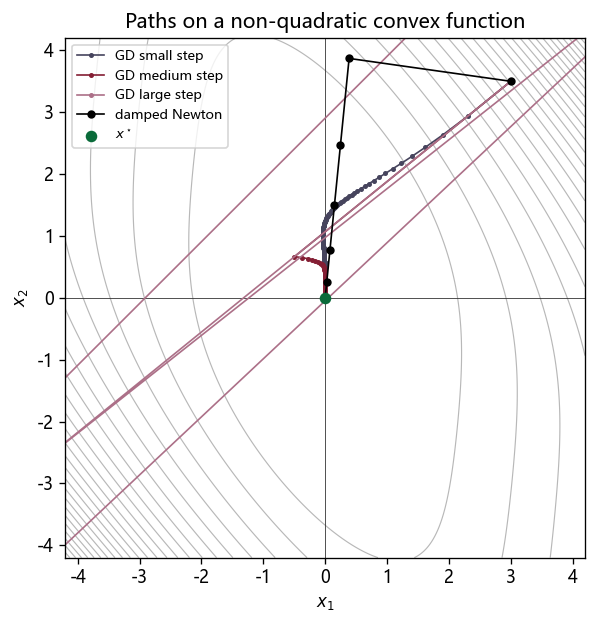

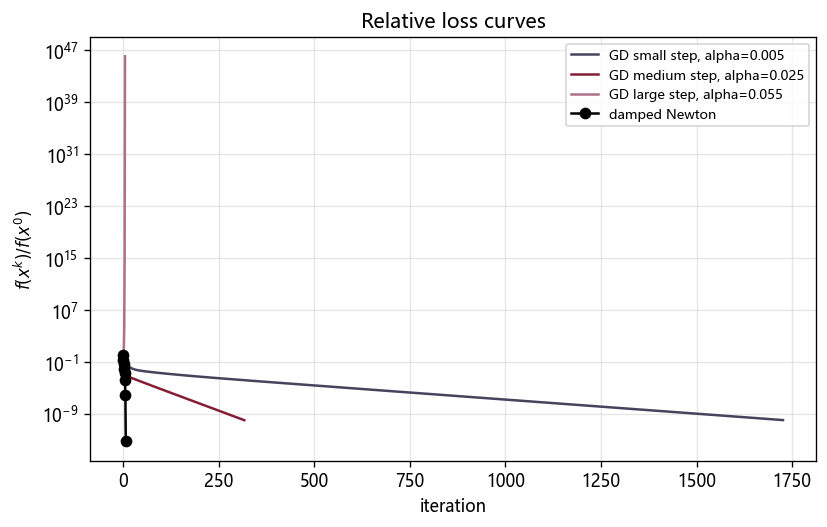

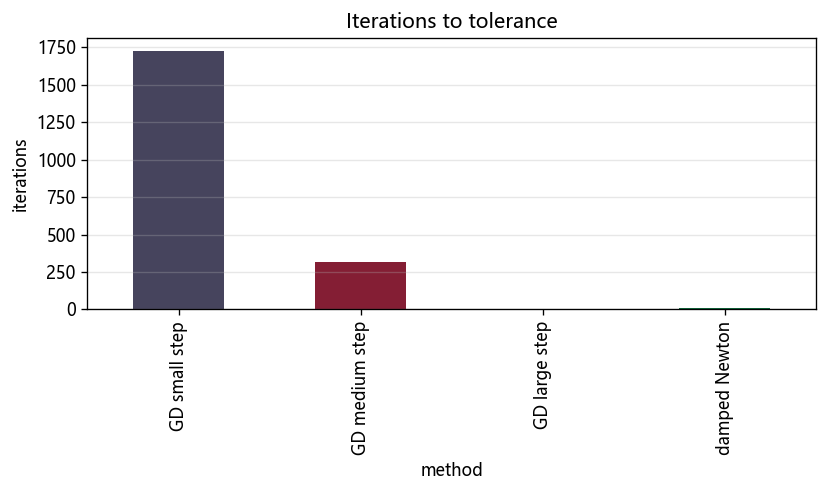

In [7]:
def nonlinear2_f(x):
    x = np.asarray(x, dtype=float)
    s = x[0] + x[1]
    return 0.5 * (10 * x[0]**2 + x[1]**2) + 0.1 * s**4


def nonlinear2_grad(x):
    x = np.asarray(x, dtype=float)
    s = x[0] + x[1]
    return np.array([
        10 * x[0] + 0.4 * s**3,
        x[1] + 0.4 * s**3,
    ])


def nonlinear2_hess(x):
    x = np.asarray(x, dtype=float)
    s = x[0] + x[1]
    return np.array([
        [10 + 1.2 * s**2, 1.2 * s**2],
        [1.2 * s**2, 1 + 1.2 * s**2],
    ])


def gd_nonlinear2(x0, alpha, tol=1e-10, max_iter=3000):
    x = np.array(x0, dtype=float)
    f0 = max(nonlinear2_f(x), 1e-300)
    xs = [x.copy()]
    fs = [nonlinear2_f(x)]
    for _ in range(max_iter):
        x = x - alpha * nonlinear2_grad(x)
        xs.append(x.copy())
        fs.append(nonlinear2_f(x))
        if fs[-1] / f0 <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e8:
            break
    return np.array(xs), np.array(fs)


def newton_nonlinear2(x0, tol=1e-10, max_iter=60, damped=True):
    x = np.array(x0, dtype=float)
    f0 = max(nonlinear2_f(x), 1e-300)
    xs = [x.copy()]
    fs = [nonlinear2_f(x)]
    alphas = []
    for _ in range(max_iter):
        g = nonlinear2_grad(x)
        H = nonlinear2_hess(x)
        d = np.linalg.solve(H, -g)
        alpha = 1.0
        if damped:
            fx = nonlinear2_f(x)
            while nonlinear2_f(x + alpha * d) > fx + 1e-4 * alpha * float(g @ d) and alpha > 1e-10:
                alpha *= 0.5
        x = x + alpha * d
        xs.append(x.copy())
        fs.append(nonlinear2_f(x))
        alphas.append(alpha)
        if fs[-1] / f0 <= tol:
            break
    return np.array(xs), np.array(fs), np.array(alphas)


def plot_nonlinear2_contours(ax, lim=4.2, levels=28):
    grid = np.linspace(-lim, lim, 350)
    X, Y = np.meshgrid(grid, grid)
    Z = 0.5 * (10 * X**2 + Y**2) + 0.1 * (X + Y)**4
    ax.contour(X, Y, Z, levels=levels, colors="0.72", linewidths=0.7)
    ax.axhline(0, color="0.2", linewidth=0.5)
    ax.axvline(0, color="0.2", linewidth=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

x0 = np.array([3.0, 3.5])
settings = [
    ("GD small step", 0.005, BLUE),
    ("GD medium step", 0.025, SHANSHU),
    ("GD large step", 0.055, ORANGE),
]

rows = []
path_records = []
loss_records = []

for name, alpha, color in settings:
    (xs, fs), runtime = timed_run(lambda a=alpha: gd_nonlinear2(x0, a), repeats=3)
    rel = fs / max(fs[0], 1e-300)
    path_records.append((name, xs, color, 2.0))
    loss_records.append((f"{name}, alpha={alpha}", rel, color, None))
    rows.append({"method": name, "alpha": alpha, "iterations": len(fs)-1, "runtime_sec": runtime, "final_loss": fs[-1]})

(xs_nt, fs_nt, alphas_nt), runtime_nt = timed_run(lambda: newton_nonlinear2(x0), repeats=50)
path_records.append(("damped Newton", xs_nt, "black", 4.0))
loss_records.append(("damped Newton", fs_nt / fs_nt[0], "black", "o"))
rows.append({"method": "damped Newton", "alpha": np.nan, "iterations": len(fs_nt)-1, "runtime_sec": runtime_nt, "final_loss": fs_nt[-1]})

compare_table = pd.DataFrame(rows)
display(compare_table)
for _, row in compare_table.iterrows():
    add_summary("nonlinear 2D", row["method"], row["iterations"], row["runtime_sec"], row["final_loss"], "experiment 2")

fig_path, ax_path = plt.subplots(figsize=(6.4, 5.3))
plot_nonlinear2_contours(ax_path)
for name, xs, color, markersize in path_records:
    ax_path.plot(xs[:, 0], xs[:, 1], "o-", color=color, markersize=markersize, linewidth=1, label=name)
ax_path.scatter([0], [0], color=DEEP_GREEN, s=35, zorder=5, label=r"$x^\star$")
ax_path.set_title("Paths on a non-quadratic convex function")
ax_path.legend(fontsize=8)
fig_path.tight_layout()
out_path = PICS / "chapter8_newton_nonlinear2d_paths.png"
fig_path.savefig(out_path, bbox_inches="tight")

fig_loss, ax_loss = plt.subplots(figsize=(7.0, 4.5))
for label, rel, color, marker in loss_records:
    if marker is None:
        ax_loss.semilogy(rel, color=color, label=label)
    else:
        ax_loss.semilogy(rel, marker + "-", color=color, label=label)
ax_loss.set_title("Relative loss curves")
ax_loss.set_xlabel("iteration")
ax_loss.set_ylabel(r"$f(x^k)/f(x^0)$")
ax_loss.grid(True, which="both", alpha=0.3)
ax_loss.legend(fontsize=8)
fig_loss.tight_layout()
out_loss = PICS / "chapter8_newton_nonlinear2d_loss.png"
fig_loss.savefig(out_loss, bbox_inches="tight")

fig_bar, ax_bar = plt.subplots(figsize=(7.0, 4.2))
compare_table.set_index("method")["iterations"].plot(kind="bar", ax=ax_bar, color=[BLUE, SHANSHU, ORANGE, DEEP_GREEN])
ax_bar.set_title("Iterations to tolerance")
ax_bar.set_ylabel("iterations")
ax_bar.grid(axis="y", alpha=0.3)
fig_bar.tight_layout()
out_bar = PICS / "chapter8_newton_nonlinear2d_iterations.png"
fig_bar.savefig(out_bar, bbox_inches="tight")

print(f"Newton alphas: {alphas_nt}")
print(f"saved to {out_path}")
print(f"saved to {out_loss}")
print(f"saved to {out_bar}")

## 实验 3：非凸函数中标准 Newton 可能失败

考虑一维非凸函数

$$
f(x)=x^4-3x^2.
$$

它的导数为

$$
f'(x)=4x^3-6x=2x(2x^2-3),
\qquad
f''(x)=12x^2-6.
$$

驻点有三个：

$$
x=0,\qquad x=\pm\sqrt{\frac32}\approx \pm 1.225.
$$

其中 $x=0$ 是局部极大点，因为 $f''(0)=-6<0$；而 $x=\pm\sqrt{3/2}$ 是两个全局最小点，最小函数值为

$$
f\!\left(\pm\sqrt{\frac32}\right)=-\frac94.
$$

本实验故意从 $x^0=0.5$ 出发。此时 $|x^0|<1/\sqrt2$，所以

$$
f''(x^0)<0.
$$

这会导致 Newton 方向不是下降方向：

$$
f'(x^k)d^k>0.
$$

因此要区分三件事：

1. **standard Newton**：只是在求解 $f'(x)=0$，所以可能收敛到局部极大点 $x=0$；
2. **只加线搜索的 damped Newton**：如果方向本身不是下降方向，线搜索只能把步长压得很小，可能几乎不动；
3. **修正 Newton**：当 Hessian 不正或方向不是下降方向时，改用负梯度方向，再配合线搜索，这样才更像实际优化算法。

standard Newton 前几步：会走向局部极大点 x=0


,k,x,f(x),g,h,d,g*d,alpha,direction
0,0,5.000000e-01,-6.875000e-01,-2.500000e+00,-3.000000,-8.333333e-01,2.083333e+00,1.0,Newton
1,1,-3.333333e-01,-3.209877e-01,1.851852e+00,-4.666667,3.968254e-01,7.348618e-01,1.0,Newton
2,2,6.349206e-02,-1.207748e-02,-3.799286e-01,-5.951625,-6.383611e-02,2.425316e-02,1.0,Newton
3,3,-3.440430e-04,-3.550968e-07,2.064258e-03,-5.999999,3.440431e-04,7.101936e-07,1.0,Newton
4,4,5.429716e-11,-8.844543e-21,-3.257829e-10,-6.000000,-5.429716e-11,1.768909e-20,1.0,Newton
5,5,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000,NaN,NaN,NaN,stop


只加线搜索的 Newton 前几步：方向不是下降方向，所以 alpha 被压得很小


,k,x,f(x),g,h,d,g*d,alpha,direction
0,0,0.5,-0.6875,-2.5,-3.0,-0.833333,2.083333,5.820766e-11,Newton
1,1,0.5,-0.6875,-2.5,-3.0,-0.833333,2.083333,5.820766e-11,Newton
2,2,0.5,-0.6875,-2.5,-3.0,-0.833333,2.083333,5.820766e-11,Newton
3,3,0.5,-0.6875,-2.5,-3.0,-0.833333,2.083333,5.820766e-11,Newton


修正 Newton 前几步：发现方向不下降时改用负梯度方向


,k,x,f(x),g,h,d,g*d,alpha,direction
0,0,0.500000,-0.687500,-2.500000e+00,-3.000000,2.500000e+00,-6.250000e+00,0.25,gradient fallback
1,1,1.125000,-2.195068,-1.054688e+00,9.187500,1.147959e-01,-1.210738e-01,1.00,Newton
2,2,1.239796,-2.248624,1.839556e-01,12.445127,-1.478133e-02,-2.719108e-03,1.00,Newton
3,3,1.225015,-2.250000,3.237645e-03,12.007929,-2.696256e-04,-8.729520e-07,1.00,Newton
4,4,1.224745,-2.250000,1.068594e-06,12.000003,-8.904951e-08,-9.515781e-14,1.00,Newton
5,5,1.224745,-2.250000,1.163514e-13,12.000000,NaN,NaN,NaN,stop


,method,final_x,final_f,iterations,comment
0,standard Newton,0.000000,0.0000,5,converges to local maximum
1,line-search-only Newton,0.500000,-0.6875,12,stalls because direction is not descent
2,modified Newton,1.224745,-2.2500,5,uses descent fallback
3,GD,1.224745,-2.2500,80,slow but stable here


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_newton_nonconvex_failure.png


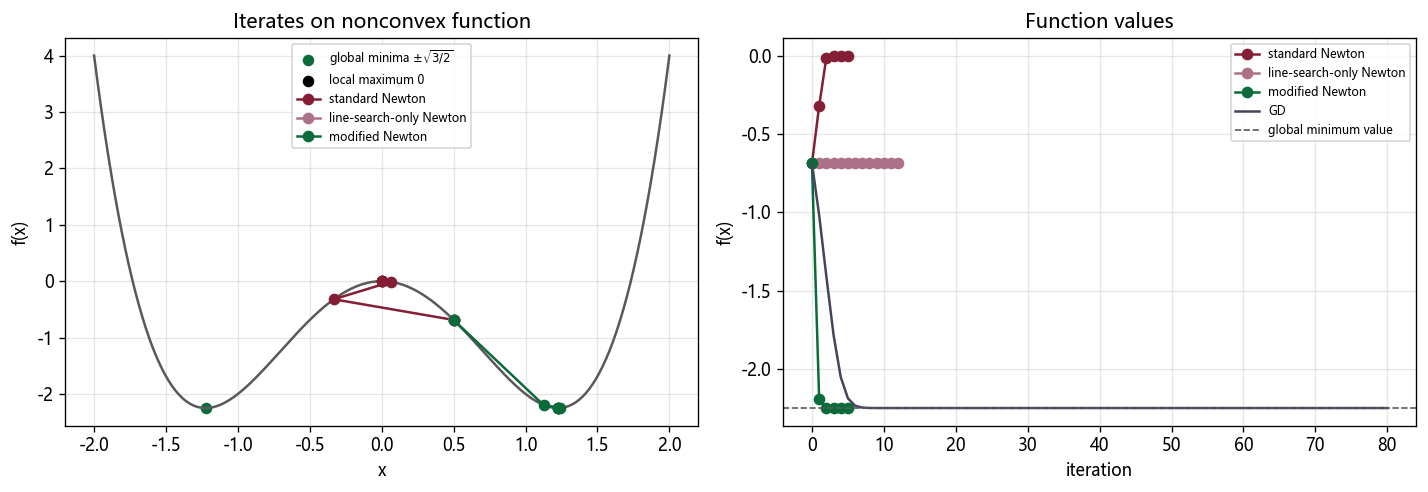

In [9]:
def nc_f(x):
    return x**4 - 3 * x**2


def nc_grad(x):
    return 4 * x**3 - 6 * x


def nc_hess(x):
    return 12 * x**2 - 6


def armijo_alpha(x, d, g, c=1e-4, beta=0.5, min_alpha=1e-10):
    alpha = 1.0
    fx = nc_f(x)
    while nc_f(x + alpha * d) > fx + c * alpha * g * d and alpha > min_alpha:
        alpha *= beta
    return alpha


def newton_1d_variant(x0, mode="standard", max_iter=12):
    """mode: standard, line_search_only, modified."""
    x = float(x0)
    rows = []
    for k in range(max_iter):
        g = nc_grad(x)
        h = nc_hess(x)
        if abs(g) < 1e-10:
            break

        if mode == "modified" and h <= 0:
            d = -g
            direction = "gradient fallback"
        else:
            if abs(h) < 1e-12:
                d = -g
                direction = "gradient fallback"
            else:
                d = -g / h
                direction = "Newton"

        gd_dot = g * d
        if mode == "modified" and gd_dot >= 0:
            d = -g
            gd_dot = g * d
            direction = "gradient fallback"

        if mode == "standard":
            alpha = 1.0
        else:
            alpha = armijo_alpha(x, d, g)

        rows.append({
            "k": k,
            "x": x,
            "f(x)": nc_f(x),
            "g": g,
            "h": h,
            "d": d,
            "g*d": gd_dot,
            "alpha": alpha,
            "direction": direction,
        })
        x = x + alpha * d
    rows.append({
        "k": len(rows),
        "x": x,
        "f(x)": nc_f(x),
        "g": nc_grad(x),
        "h": nc_hess(x),
        "d": np.nan,
        "g*d": np.nan,
        "alpha": np.nan,
        "direction": "stop",
    })
    return pd.DataFrame(rows)


def gd_1d(x0, alpha=0.05, max_iter=80):
    x = float(x0)
    rows = []
    for k in range(max_iter):
        rows.append({"k": k, "x": x, "f(x)": nc_f(x)})
        x = x - alpha * nc_grad(x)
    rows.append({"k": max_iter, "x": x, "f(x)": nc_f(x)})
    return pd.DataFrame(rows)

std = newton_1d_variant(0.5, mode="standard")
ls_only = newton_1d_variant(0.5, mode="line_search_only")
mod = newton_1d_variant(0.5, mode="modified")
gd = gd_1d(0.5, alpha=0.05)

print("standard Newton 前几步：会走向局部极大点 x=0")
display(std.head(6))
print("只加线搜索的 Newton 前几步：方向不是下降方向，所以 alpha 被压得很小")
display(ls_only.head(4))
print("修正 Newton 前几步：发现方向不下降时改用负梯度方向")
display(mod.head(6))

final_table = pd.DataFrame([
    {"method": "standard Newton", "final_x": std["x"].iloc[-1], "final_f": std["f(x)"].iloc[-1], "iterations": len(std)-1, "comment": "converges to local maximum"},
    {"method": "line-search-only Newton", "final_x": ls_only["x"].iloc[-1], "final_f": ls_only["f(x)"].iloc[-1], "iterations": len(ls_only)-1, "comment": "stalls because direction is not descent"},
    {"method": "modified Newton", "final_x": mod["x"].iloc[-1], "final_f": mod["f(x)"].iloc[-1], "iterations": len(mod)-1, "comment": "uses descent fallback"},
    {"method": "GD", "final_x": gd["x"].iloc[-1], "final_f": gd["f(x)"].iloc[-1], "iterations": len(gd)-1, "comment": "slow but stable here"},
])
display(final_table)

add_summary("nonconvex", "standard Newton", len(std)-1, np.nan, std["f(x)"].iloc[-1], "converges to local max")
add_summary("nonconvex", "line-search-only Newton", len(ls_only)-1, np.nan, ls_only["f(x)"].iloc[-1], "stalls on non-descent direction")
add_summary("nonconvex", "modified Newton", len(mod)-1, np.nan, mod["f(x)"].iloc[-1], "descent fallback")
add_summary("nonconvex", "GD", len(gd)-1, np.nan, gd["f(x)"].iloc[-1])

xx = np.linspace(-2, 2, 500)
x_min = np.sqrt(1.5)
f_min = nc_f(x_min)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(xx, nc_f(xx), color="0.35")
axes[0].scatter([x_min, -x_min], [f_min, f_min], color=DEEP_GREEN, s=35, label=r"global minima $\pm\sqrt{3/2}$")
axes[0].scatter([0], [0], color="black", s=35, label="local maximum 0")
axes[0].plot(std["x"], std["f(x)"], "o-", color=SHANSHU, label="standard Newton")
axes[0].plot(ls_only["x"], ls_only["f(x)"], "o-", color=ORANGE, label="line-search-only Newton")
axes[0].plot(mod["x"], mod["f(x)"], "o-", color=DEEP_GREEN, label="modified Newton")
axes[0].set_title("Iterates on nonconvex function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].plot(std["k"], std["f(x)"], "o-", color=SHANSHU, label="standard Newton")
axes[1].plot(ls_only["k"], ls_only["f(x)"], "o-", color=ORANGE, label="line-search-only Newton")
axes[1].plot(mod["k"], mod["f(x)"], "o-", color=DEEP_GREEN, label="modified Newton")
axes[1].plot(gd["k"], gd["f(x)"], color=BLUE, label="GD")
axes[1].axhline(f_min, color="0.35", linestyle="--", linewidth=1, label="global minimum value")
axes[1].set_title("Function values")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("f(x)")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_newton_nonconvex_failure.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 4：非线性曲线拟合，GD vs Gauss-Newton

这一节模拟一个实际曲线拟合问题。假设观测数据来自指数衰减模型

$$
y_i=a e^{bt_i}+\epsilon_i,
$$

其中 $a,b$ 是未知参数，$\epsilon_i$ 是噪声。我们的目标是根据数据反推出 $a,b$。

把参数记为

$$
\theta=(a,b)^T,
$$

残差为

$$
r_i(\theta)=a e^{bt_i}-y_i.
$$

要最小化的目标函数是残差平方和：

$$
F(\theta)=\frac12\sum_{i=1}^m r_i(\theta)^2=\frac12\|r(\theta)\|^2.
$$

这不是线性最小二乘，因为 $b$ 出现在指数函数里，所以目标函数不是二次函数。

GD 使用梯度

$$
\nabla F(\theta)=J(\theta)^T r(\theta),
$$

其中 $J(\theta)$ 是残差向量对参数的 Jacobian 矩阵。Gauss-Newton 则进一步利用最小二乘结构，近似求解

$$
J(\theta)^TJ(\theta)d=-J(\theta)^Tr(\theta).
$$

直观上，Gauss-Newton 每一步都把非线性残差局部线性化，然后解一个线性最小二乘问题。

本实验比较 GD、Gauss-Newton 和阻尼 Gauss-Newton 的迭代次数、runtime、loss 曲线以及最终拟合曲线。重点观察：在非线性最小二乘中，Gauss-Newton 往往比普通 GD 更接近实际工程算法。

,method,iterations,runtime_sec,final_loss,a,b
0,GD,3000,0.122422,0.119922,2.47128,-0.788887
1,Gauss-Newton,7,0.000710,0.119922,2.47128,-0.788887
2,damped Gauss-Newton,7,0.001318,0.119922,2.47128,-0.788887


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_newton_gauss_newton_curve_fit.png


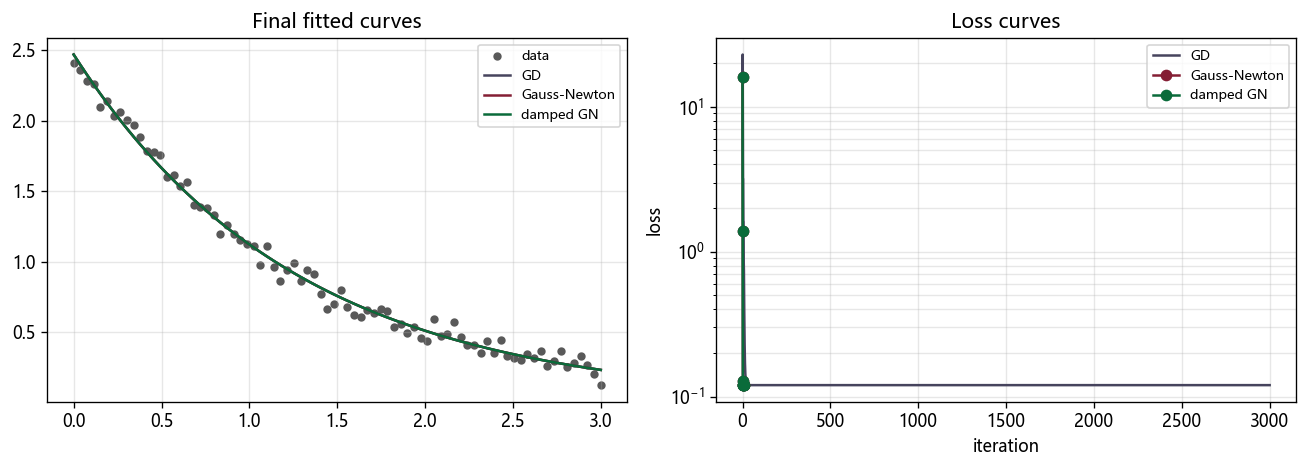

In [8]:
rng = np.random.default_rng(8)
t = np.linspace(0, 3, 80)
true_theta = np.array([2.5, -0.8])
y = true_theta[0] * np.exp(true_theta[1] * t) + 0.05 * rng.normal(size=t.size)


def residual(theta):
    a, b = theta
    return a * np.exp(b * t) - y


def jacobian(theta):
    a, b = theta
    e = np.exp(b * t)
    return np.column_stack([e, a * t * e])


def nls_loss(theta):
    r = residual(theta)
    return 0.5 * float(r @ r)


def gd_curve_fit(theta0, alpha=0.02, max_iter=3000, tol=1e-10):
    theta = np.array(theta0, dtype=float)
    rows = []
    f0 = nls_loss(theta)
    for _ in range(max_iter):
        rows.append({"k": len(rows), "a": theta[0], "b": theta[1], "loss": nls_loss(theta)})
        g = jacobian(theta).T @ residual(theta)
        theta = theta - alpha * g
        if nls_loss(theta) / max(f0, 1e-300) < tol:
            break
    rows.append({"k": len(rows), "a": theta[0], "b": theta[1], "loss": nls_loss(theta)})
    return pd.DataFrame(rows)


def gauss_newton(theta0, max_iter=80, damped=True):
    theta = np.array(theta0, dtype=float)
    rows = []
    for k in range(max_iter):
        r = residual(theta)
        J = jacobian(theta)
        loss = 0.5 * float(r @ r)
        g = J.T @ r
        H_approx = J.T @ J
        d = np.linalg.solve(H_approx + 1e-8 * np.eye(2), -g)
        alpha = 1.0
        if damped:
            while nls_loss(theta + alpha * d) > loss + 1e-4 * alpha * float(g @ d) and alpha > 1e-10:
                alpha *= 0.5
        rows.append({"k": k, "a": theta[0], "b": theta[1], "loss": loss, "alpha": alpha})
        theta = theta + alpha * d
        if np.linalg.norm(g) < 1e-8:
            break
    rows.append({"k": len(rows), "a": theta[0], "b": theta[1], "loss": nls_loss(theta), "alpha": np.nan})
    return pd.DataFrame(rows)

theta0 = np.array([1.0, 0.0])
(gd_fit, t_gd_fit) = timed_run(lambda: gd_curve_fit(theta0), repeats=1)
(gn_fit, t_gn_fit) = timed_run(lambda: gauss_newton(theta0, damped=False), repeats=20)
(dgn_fit, t_dgn_fit) = timed_run(lambda: gauss_newton(theta0, damped=True), repeats=20)

fit_table = pd.DataFrame([
    {"method": "GD", "iterations": len(gd_fit)-1, "runtime_sec": t_gd_fit, "final_loss": gd_fit["loss"].iloc[-1], "a": gd_fit["a"].iloc[-1], "b": gd_fit["b"].iloc[-1]},
    {"method": "Gauss-Newton", "iterations": len(gn_fit)-1, "runtime_sec": t_gn_fit, "final_loss": gn_fit["loss"].iloc[-1], "a": gn_fit["a"].iloc[-1], "b": gn_fit["b"].iloc[-1]},
    {"method": "damped Gauss-Newton", "iterations": len(dgn_fit)-1, "runtime_sec": t_dgn_fit, "final_loss": dgn_fit["loss"].iloc[-1], "a": dgn_fit["a"].iloc[-1], "b": dgn_fit["b"].iloc[-1]},
])
display(fit_table)
for _, row in fit_table.iterrows():
    add_summary("curve fitting", row["method"], row["iterations"], row["runtime_sec"], row["final_loss"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].scatter(t, y, s=16, color="0.35", label="data")
for df, name, color in [(gd_fit, "GD", BLUE), (gn_fit, "Gauss-Newton", SHANSHU), (dgn_fit, "damped GN", DEEP_GREEN)]:
    theta = df[["a", "b"]].iloc[-1].to_numpy()
    axes[0].plot(t, theta[0] * np.exp(theta[1] * t), color=color, label=name)
axes[0].set_title("Final fitted curves")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].semilogy(gd_fit["k"], gd_fit["loss"], color=BLUE, label="GD")
axes[1].semilogy(gn_fit["k"], gn_fit["loss"], "o-", color=SHANSHU, label="Gauss-Newton")
axes[1].semilogy(dgn_fit["k"], dgn_fit["loss"], "o-", color=DEEP_GREEN, label="damped GN")
axes[1].set_title("Loss curves")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("loss")
axes[1].legend(fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_newton_gauss_newton_curve_fit.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 5：Logistic 回归，GD vs 阻尼 Newton

这一节用一个二维二分类数据集演示 Logistic 回归。每个样本有两个特征 $x_1,x_2$，标签为 0 或 1。我们使用带截距项的线性分类器

$$
p_i=\sigma(w_0+w_1x_{i1}+w_2x_{i2}),
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Logistic 回归通过最小化负对数似然来学习参数 $w$：

$$
F(w)=\sum_{i=1}^m \left[\log(1+e^{a_i^Tw})-y_i a_i^Tw\right]+\frac{\lambda}{2}\|w_{1:}\|^2.
$$

这里加了一个很小的正则项，主要是为了让 Hessian 更稳定。

GD 每一步使用

$$
w^{k+1}=w^k-\alpha \nabla F(w^k),
$$

而 Newton 法每一步解

$$
\nabla^2F(w^k)d^k=-\nabla F(w^k).
$$

Logistic 回归不是二次函数，所以 Newton 不会一步到达最优点；但它会利用 Hessian 中的局部曲率信息，通常迭代次数明显少于 GD。

这个实验不作为 PPT 主案例，但可以用来观察一个典型权衡：Newton 每一步更贵，但迭代次数更少。这里比较 loss 曲线、runtime 和最终分类边界。

In [ ]:
rng = np.random.default_rng(12)
n_per_class = 120
X_pos = rng.normal(loc=[1.5, 1.0], scale=0.75, size=(n_per_class, 2))
X_neg = rng.normal(loc=[-1.2, -1.0], scale=0.8, size=(n_per_class, 2))
X_raw = np.vstack([X_pos, X_neg])
y_log = np.hstack([np.ones(n_per_class), np.zeros(n_per_class)])
X = np.column_stack([np.ones(X_raw.shape[0]), X_raw])


def logistic_loss(w, reg=1e-3):
    z = X @ w
    return float(np.sum(np.logaddexp(0, z) - y_log * z) + 0.5 * reg * (w[1:] @ w[1:]))


def logistic_grad(w, reg=1e-3):
    z = X @ w
    p = 1 / (1 + np.exp(-z))
    g = X.T @ (p - y_log)
    g[1:] += reg * w[1:]
    return g


def logistic_hess(w, reg=1e-3):
    z = X @ w
    p = 1 / (1 + np.exp(-z))
    s = p * (1 - p)
    H = X.T @ (s[:, None] * X)
    H[1:, 1:] += reg * np.eye(X.shape[1] - 1)
    return H


def gd_logistic(alpha=0.03, max_iter=3000, tol=1e-8):
    w = np.zeros(X.shape[1])
    rows = []
    f0 = logistic_loss(w)
    for _ in range(max_iter):
        rows.append({"k": len(rows), "loss": logistic_loss(w)})
        w = w - alpha * logistic_grad(w)
        if logistic_loss(w) / f0 < tol:
            break
    rows.append({"k": len(rows), "loss": logistic_loss(w)})
    return w, pd.DataFrame(rows)


def newton_logistic(max_iter=40):
    w = np.zeros(X.shape[1])
    rows = []
    for k in range(max_iter):
        loss = logistic_loss(w)
        g = logistic_grad(w)
        H = logistic_hess(w)
        d = np.linalg.solve(H, -g)
        alpha = 1.0
        while logistic_loss(w + alpha * d) > loss + 1e-4 * alpha * float(g @ d) and alpha > 1e-10:
            alpha *= 0.5
        rows.append({"k": k, "loss": loss, "alpha": alpha})
        w = w + alpha * d
        if np.linalg.norm(g) < 1e-7:
            break
    rows.append({"k": len(rows), "loss": logistic_loss(w), "alpha": np.nan})
    return w, pd.DataFrame(rows)

((w_gd, log_gd), t_log_gd) = timed_run(lambda: gd_logistic(), repeats=1)
((w_nt, log_nt), t_log_nt) = timed_run(lambda: newton_logistic(), repeats=20)

log_table = pd.DataFrame([
    {"method": "GD", "iterations": len(log_gd)-1, "runtime_sec": t_log_gd, "final_loss": log_gd["loss"].iloc[-1]},
    {"method": "damped Newton", "iterations": len(log_nt)-1, "runtime_sec": t_log_nt, "final_loss": log_nt["loss"].iloc[-1]},
])
display(log_table)
for _, row in log_table.iterrows():
    add_summary("logistic", row["method"], row["iterations"], row["runtime_sec"], row["final_loss"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].semilogy(log_gd["k"], log_gd["loss"], color=BLUE, label="GD")
axes[0].semilogy(log_nt["k"], log_nt["loss"], "o-", color=SHANSHU, label="damped Newton")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].scatter(X_pos[:, 0], X_pos[:, 1], s=18, color=DEEP_GREEN, label="class 1")
axes[1].scatter(X_neg[:, 0], X_neg[:, 1], s=18, color=ORANGE, label="class 0")
xx = np.linspace(X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5, 200)
for w, name, color in [(w_gd, "GD", BLUE), (w_nt, "Newton", SHANSHU)]:
    yy = -(w[0] + w[1] * xx) / w[2]
    axes[1].plot(xx, yy, color=color, label=name)
axes[1].set_title("Decision boundaries")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_newton_logistic_runtime.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 6：内点法 barrier 子问题中的 Newton 步

这一节展示 Newton 法在约束优化中的一种典型用法。考虑一个简化的投资组合问题：选择三个资产的权重

$$
x=(x_1,x_2,x_3)^T,
$$

要求资金全部分配出去，并且不能做空：

$$
\sum_i x_i=1,\qquad x_i>0.
$$

目标函数可以写成

$$
\frac12x^TQx-c^Tx,
$$

其中 $Q$ 可以理解为风险矩阵，$c$ 可以理解为收益向量。直接处理 $x_i>0$ 这个约束并不方便。内点法把不等式约束放进 barrier 项：

$$
\min_x \frac12x^TQx-c^Tx-\mu\sum_i\log x_i,
\qquad \sum_i x_i=1,\quad x_i>0.
$$

当某个 $x_i$ 接近 0 时，$-\log x_i$ 会快速变大，因此 barrier 项会把迭代点留在可行区域内部。

由于还有等式约束 $\sum_i x_i=1$，Newton 步不再是简单的

$$
Hd=-g,
$$

而是来自 KKT 线性系统：同时求变量步长 $d$ 和乘子修正 $\Delta\lambda$。

本实验比较不同 $\mu$ 下 barrier 子问题的 Newton 迭代。重点观察：$\mu$ 越小，barrier 越弱，解会更接近原始约束优化问题的解；同时 Newton 步会始终保持 $x_i>0$。

In [ ]:
Q_port = np.array([[0.20, 0.04, 0.02], [0.04, 0.12, 0.03], [0.02, 0.03, 0.16]])
c_port = np.array([0.10, 0.16, 0.13])
A_port = np.ones((1, 3))
b_port = np.array([1.0])


def barrier_value(x, mu):
    if np.any(x <= 0):
        return np.inf
    return 0.5 * float(x @ Q_port @ x) - float(c_port @ x) - mu * float(np.sum(np.log(x)))


def barrier_grad_hess(x, mu):
    g = Q_port @ x - c_port - mu / x
    H = Q_port + np.diag(mu / (x**2))
    return g, H


def barrier_newton(mu=0.1, x0=None, max_iter=40):
    x = np.ones(3) / 3 if x0 is None else np.array(x0, dtype=float)
    lam = np.array([0.0])
    rows = []
    for k in range(max_iter):
        val = barrier_value(x, mu)
        g, H = barrier_grad_hess(x, mu)
        r_pri = A_port @ x - b_port
        KKT = np.block([[H, A_port.T], [A_port, np.zeros((1, 1))]])
        rhs = -np.concatenate([g + A_port.T @ lam, r_pri])
        step = np.linalg.solve(KKT, rhs)
        d = step[:3]
        dlam = step[3:]
        alpha = 1.0
        while np.any(x + alpha * d <= 0):
            alpha *= 0.5
        while barrier_value(x + alpha * d, mu) > val + 1e-4 * alpha * float(g @ d) and alpha > 1e-10:
            alpha *= 0.5
        rows.append({"k": k, "mu": mu, "value": val, "alpha": alpha, "x1": x[0], "x2": x[1], "x3": x[2]})
        x = x + alpha * d
        lam = lam + alpha * dlam
        if np.linalg.norm(d) < 1e-10:
            break
    rows.append({"k": len(rows), "mu": mu, "value": barrier_value(x, mu), "alpha": np.nan, "x1": x[0], "x2": x[1], "x3": x[2]})
    return pd.DataFrame(rows)

mus = [1.0, 0.3, 0.1, 0.03, 0.01]
barrier_runs = []
for mu in mus:
    df = barrier_newton(mu)
    barrier_runs.append(df)
    add_summary("barrier", f"Newton, mu={mu}", len(df)-1, np.nan, df["value"].iloc[-1])

barrier_table = pd.DataFrame([
    {"mu": df["mu"].iloc[0], "iterations": len(df)-1, "x1": df["x1"].iloc[-1], "x2": df["x2"].iloc[-1], "x3": df["x3"].iloc[-1], "value": df["value"].iloc[-1]}
    for df in barrier_runs
])
display(barrier_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for df in barrier_runs:
    label = fr"$\mu={df['mu'].iloc[0]}$"
    axes[0].plot(df["k"], df["value"], "o-", label=label)
axes[0].set_title("Barrier objective during Newton steps")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("barrier value")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

width = 0.22
idx = np.arange(len(barrier_table))
for j, col in enumerate(["x1", "x2", "x3"]):
    axes[1].bar(idx + (j - 1) * width, barrier_table[col], width=width, label=col)
axes[1].set_xticks(idx)
axes[1].set_xticklabels([str(mu) for mu in barrier_table["mu"]])
axes[1].set_xlabel(r"barrier parameter $\mu$")
axes[1].set_ylabel("portfolio weight")
axes[1].set_title("Solution changes as barrier weakens")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_newton_barrier_method.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 7：分层比较总结

前面几个实验展示了 Newton 类方法在不同层次上的表现：

1. **严格二次函数**：Newton 一步到最优点，GD 受条件数影响明显；
2. **非二次凸函数**：Newton 不再一步到达，但通常比 GD 需要更少迭代；
3. **非凸函数**：标准 Newton 可能收敛到局部极大点，只加线搜索也可能卡住，需要方向修正；
4. **非线性最小二乘**：Gauss-Newton 利用残差结构，是实际曲线拟合中常见的 Newton 类方法；
5. **Logistic 回归**：Newton 每步更贵，但迭代次数通常更少；
6. **约束优化 barrier 子问题**：Newton 步通过 KKT 系统出现，是内点法的核心组成部分。

这一节把前面实验得到的迭代次数和 runtime 汇总起来。注意：小规模教学例子的 runtime 会受到机器、Python 开销和绘图影响，不应过度解读绝对时间。课堂上更应关注这些结构性差异：是否需要调步长、是否利用曲率、是否保证下降、是否适合大规模问题。

In [ ]:
summary_df = pd.DataFrame(summaries)
summary_df = summary_df.sort_values(["experiment", "method"]).reset_index(drop=True)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_df = summary_df.dropna(subset=["iterations"]).copy()
plot_df["label"] = plot_df["experiment"] + " | " + plot_df["method"]
axes[0].barh(plot_df["label"], plot_df["iterations"], color=SHANSHU)
axes[0].set_title("Iterations across experiments")
axes[0].set_xlabel("iterations")
axes[0].grid(axis="x", alpha=0.3)

runtime_df = summary_df.dropna(subset=["runtime_sec"]).copy()
runtime_df["label"] = runtime_df["experiment"] + " | " + runtime_df["method"]
axes[1].barh(runtime_df["label"], runtime_df["runtime_sec"], color=DEEP_GREEN)
axes[1].set_title("Runtime across experiments")
axes[1].set_xlabel("seconds")
axes[1].grid(axis="x", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_newton_experiment_summary.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")